# Airline Customer Experience & Sentiment Analytics

**Python portfolio case study | Customer Experience | Voice of Customer | Decision Support**

## Project Snapshot

**Role:** Business / Data Analyst  
**Project:** Airline Customer Experience & Sentiment Analytics  
**Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn | NLTK | scikit-learn | Gensim  
**Techniques:** Data Cleaning | Exploratory Data Analysis | Performance Benchmarking | Sentiment Analysis | NLP | LDA Topic Modelling  
**Dataset:** 50,000 sampled passenger reviews  

This notebook analyses airline passenger reviews to identify service-performance gaps, customer sentiment patterns, recurring experience themes and actionable opportunities for business decision-making.

## Contents

1. Executive Summary
2. Data Exploration & Preparation
3. Sentiment Analysis
4. Topic Modelling
5. Practical Implications & Recommendations
6. References

## AI Assistance Disclosure

Gemini was used in July 2025 to help diagnose Python errors and suggest improvements to code logic and functionality. Suggestions were critically reviewed; the final analysis, interpretations and conclusions are the author’s own. Sources used in the analysis are retained in the References section.

# **1. EXECUTIVE SUMMARY**

This report addresses a strategic business need for Insight IQ's client, an established Australian airline to understand how airline passengers evaluate service experiences, identify gaps in performance, and inform opportunities for service improvement and competitive differentiation. Using a sample of 50,000 passenger reviews, the project aimed to explore what passengers value most, how sentiment and service ratings vary across airlines, and how the client compares with both top performing and low performing competitors.

Applying the BACCM framework, the business need centres on improving customer satisfaction and brand perception. The proposed change involves leveraging data driven insights to enhance service delivery across critical touchpoints. The solution presented is a comprehensive analysis of customer sentiment, topic modelling, and service specific ratings. Stakeholders include airline executives, customer experience managers, and operational teams. The expected value includes improved recommendation rates, stronger customer loyalty, and reduced service related complaints. The context is a highly competitive post pandemic airline industry with increased service expectations.

The analysis revealed that the client’s carriers, Qantas Airways and Jetstar Airways do not rank in the top 10 for overall or category specific performance (Sections A, B). Ratings for key services such as food, entertainment, and Wi Fi remain below those of top global airlines. Topic modelling identified in flight experience, delays, and baggage handling as dominant passenger concerns (Section E), while sentiment analysis confirmed that top rated airlines such as Hainan Airlines and ANA All Nippon Airways receive consistently positive emotional feedback (Section C).

In contrast, lower rated airlines show concentrated negative sentiment around delays and operational reliability (Section F). These findings suggest that targeted improvements in service consistency, in flight comfort, and customer communication could drive measurable gains in passenger satisfaction.

The report provides a clear, evidence based direction for enhancing customer experience and strengthening the client’s competitive market position.



---



---



# **2. DATA EXPLORATION**

#**2.1 Data Preparation**

In [1]:
import pandas as pd

df = pd.read_csv('A1_dataset.csv')
df.head()

seed = 223739717  # fixed seed retained to reproduce the original 50,000-review sample
sample_df = df.sample(n=50000, random_state=seed)

In [2]:
# Defind a function to clean text
def preprocess(ReviewText):
    ReviewText = ReviewText.str.replace("(<br/>)", "")
    ReviewText = ReviewText.str.replace('(<a).*(>).*(</a>)', '')
    ReviewText = ReviewText.str.replace('(&amp)', '')
    ReviewText = ReviewText.str.replace('(&gt)', '')
    ReviewText = ReviewText.str.replace('(&lt)', '')
    ReviewText = ReviewText.str.replace('(\xa0)', ' ')
    ReviewText = ReviewText.str.replace('.', '')
    return ReviewText

# explore the dataset
print('Sample size:', sample_df.shape[0])
print('Number of columns:', sample_df.shape[1])
print('\nColumn names and data types:')
display(sample_df.info())
display(sample_df.isnull().sum())

Sample size: 50000
Number of columns: 17

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 39187 to 6066
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   AirlineName          50000 non-null  object
 1   CabinType            50000 non-null  object
 2   DateFlown            50000 non-null  object
 3   EntertainmentRating  50000 non-null  int64 
 4   FoodRating           50000 non-null  int64 
 5   GroundServiceRating  50000 non-null  int64 
 6   OriginCountry        50000 non-null  object
 7   OverallScore         50000 non-null  int64 
 8   Recommended          50000 non-null  object
 9   Review               50000 non-null  object
 10  SeatComfortRating    50000 non-null  int64 
 11  ServiceRating        50000 non-null  int64 
 12  Title                50000 non-null  object
 13  TravelType           50000 non-null  object
 14  ValueRating          50000 non-nu

None

,0
AirlineName,0
CabinType,0
DateFlown,0
EntertainmentRating,0
FoodRating,0
GroundServiceRating,0
OriginCountry,0
OverallScore,0
Recommended,0
Review,0


In [3]:
sample_df.describe()

,EntertainmentRating,FoodRating,GroundServiceRating,OverallScore,SeatComfortRating,ServiceRating,ValueRating,WifiRating,unique_id
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,1.513000,1.882660,2.321660,3.922960,2.434580,2.67428,2.447180,0.667380,36926.293580
std,1.733312,1.745094,1.629469,3.415965,1.548421,1.70810,1.593594,1.248525,21349.032635
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000,18497.750000
50%,1.000000,1.000000,1.000000,2.000000,2.000000,3.00000,2.000000,0.000000,36843.000000
75%,3.000000,3.000000,4.000000,7.000000,4.000000,4.00000,4.000000,1.000000,55358.500000
max,5.000000,5.000000,5.000000,10.000000,5.000000,5.00000,5.000000,5.000000,74000.000000


#**2.2 PART A**

### **2.2.1 Top 10 airlines based on the overall rating across various cabin types.**

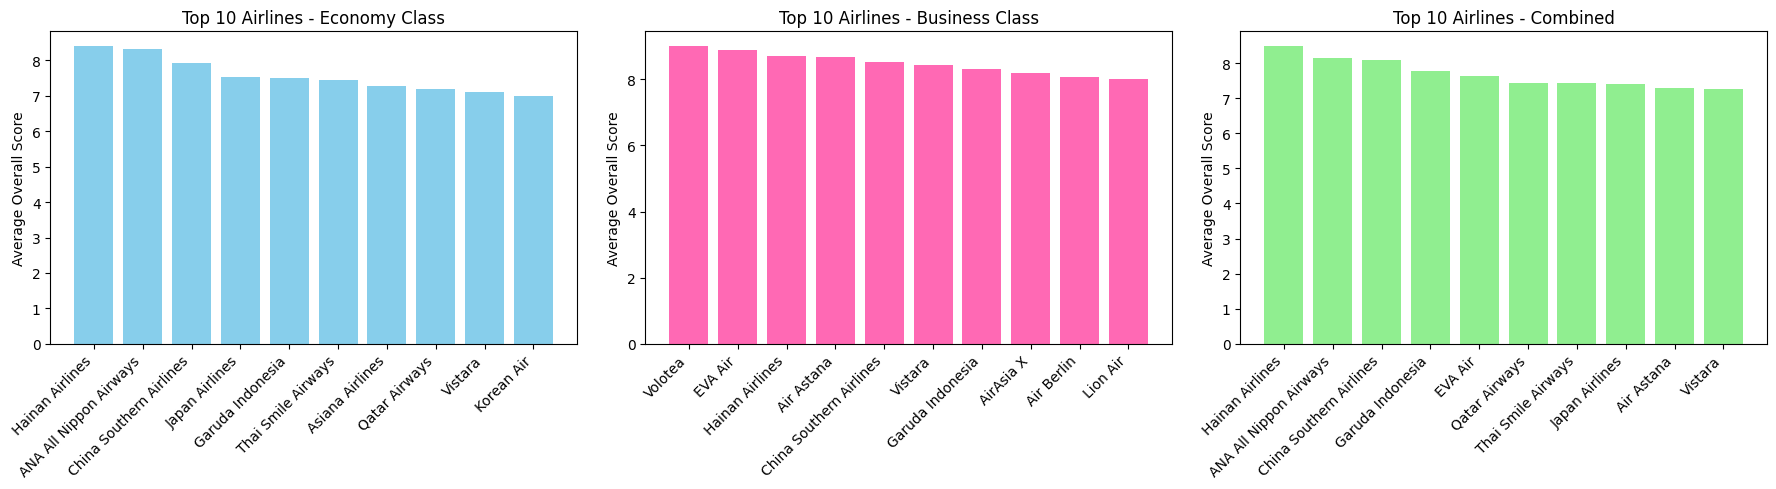

In [4]:
from matplotlib import pyplot

# Group by Airline and CabinType, and calculate average overall score
avg_scores = sample_df.groupby(['AirlineName', 'CabinType'])['OverallScore'].mean().reset_index()

# Calculate combined overall average score
avg_scores_combined = sample_df.groupby('AirlineName')['OverallScore'].mean().reset_index()

# Separate Economy and Business class, and get top 10
economy_sample_df = avg_scores[avg_scores['CabinType'] == 'Economy Class'].sort_values(by='OverallScore', ascending=False).head(10)
business_sample_df = avg_scores[avg_scores['CabinType'] == 'Business Class'].sort_values(by='OverallScore', ascending=False).head(10)
combined_sample_df = avg_scores_combined.sort_values(by='OverallScore', ascending=False).head(10)

# Set up subplots
pyplot.figure(figsize=(18, 5))

# Plot 1: Economy Class
pyplot.subplot(1, 3, 1)
pyplot.bar(economy_sample_df['AirlineName'], economy_sample_df['OverallScore'], color='skyblue')
pyplot.title('Top 10 Airlines - Economy Class')
pyplot.ylabel('Average Overall Score')
pyplot.xticks(rotation=45, ha='right')

# Plot 2: Business Class
pyplot.subplot(1, 3, 2)
pyplot.bar(business_sample_df['AirlineName'], business_sample_df['OverallScore'], color='hotpink')
pyplot.title('Top 10 Airlines - Business Class')
pyplot.ylabel('Average Overall Score')
pyplot.xticks(rotation=45, ha='right')

# Plot 3: Combined (All Classes)
pyplot.subplot(1, 3, 3)
pyplot.bar(combined_sample_df['AirlineName'], combined_sample_df['OverallScore'], color='lightgreen')
pyplot.title('Top 10 Airlines - Combined')
pyplot.ylabel('Average Overall Score')
pyplot.xticks(rotation=45, ha='right')

pyplot.tight_layout()
pyplot.show()


**Top 10 Airlines by Overall Rating**

---



The analysis identified the top 10 airlines across Economy, Business, and Combined classes based on average overall scores from 50,000 customer reviews. In Economy class, Hainan Airlines, ANA All Nippon Airways, and China Southern Airlines emerged as top performers. Volotea, EVA Air, and Hainan Airlines led in Business class, all with average ratings above 8.5. When combined, Hainan Airlines consistently ranked first, followed by ANA All Nippon Airways and China Southern Airlines.

### **2.2.2 Top Airline Rankings Across Key Service Categories(Entertainment, Food, Ground Service)**

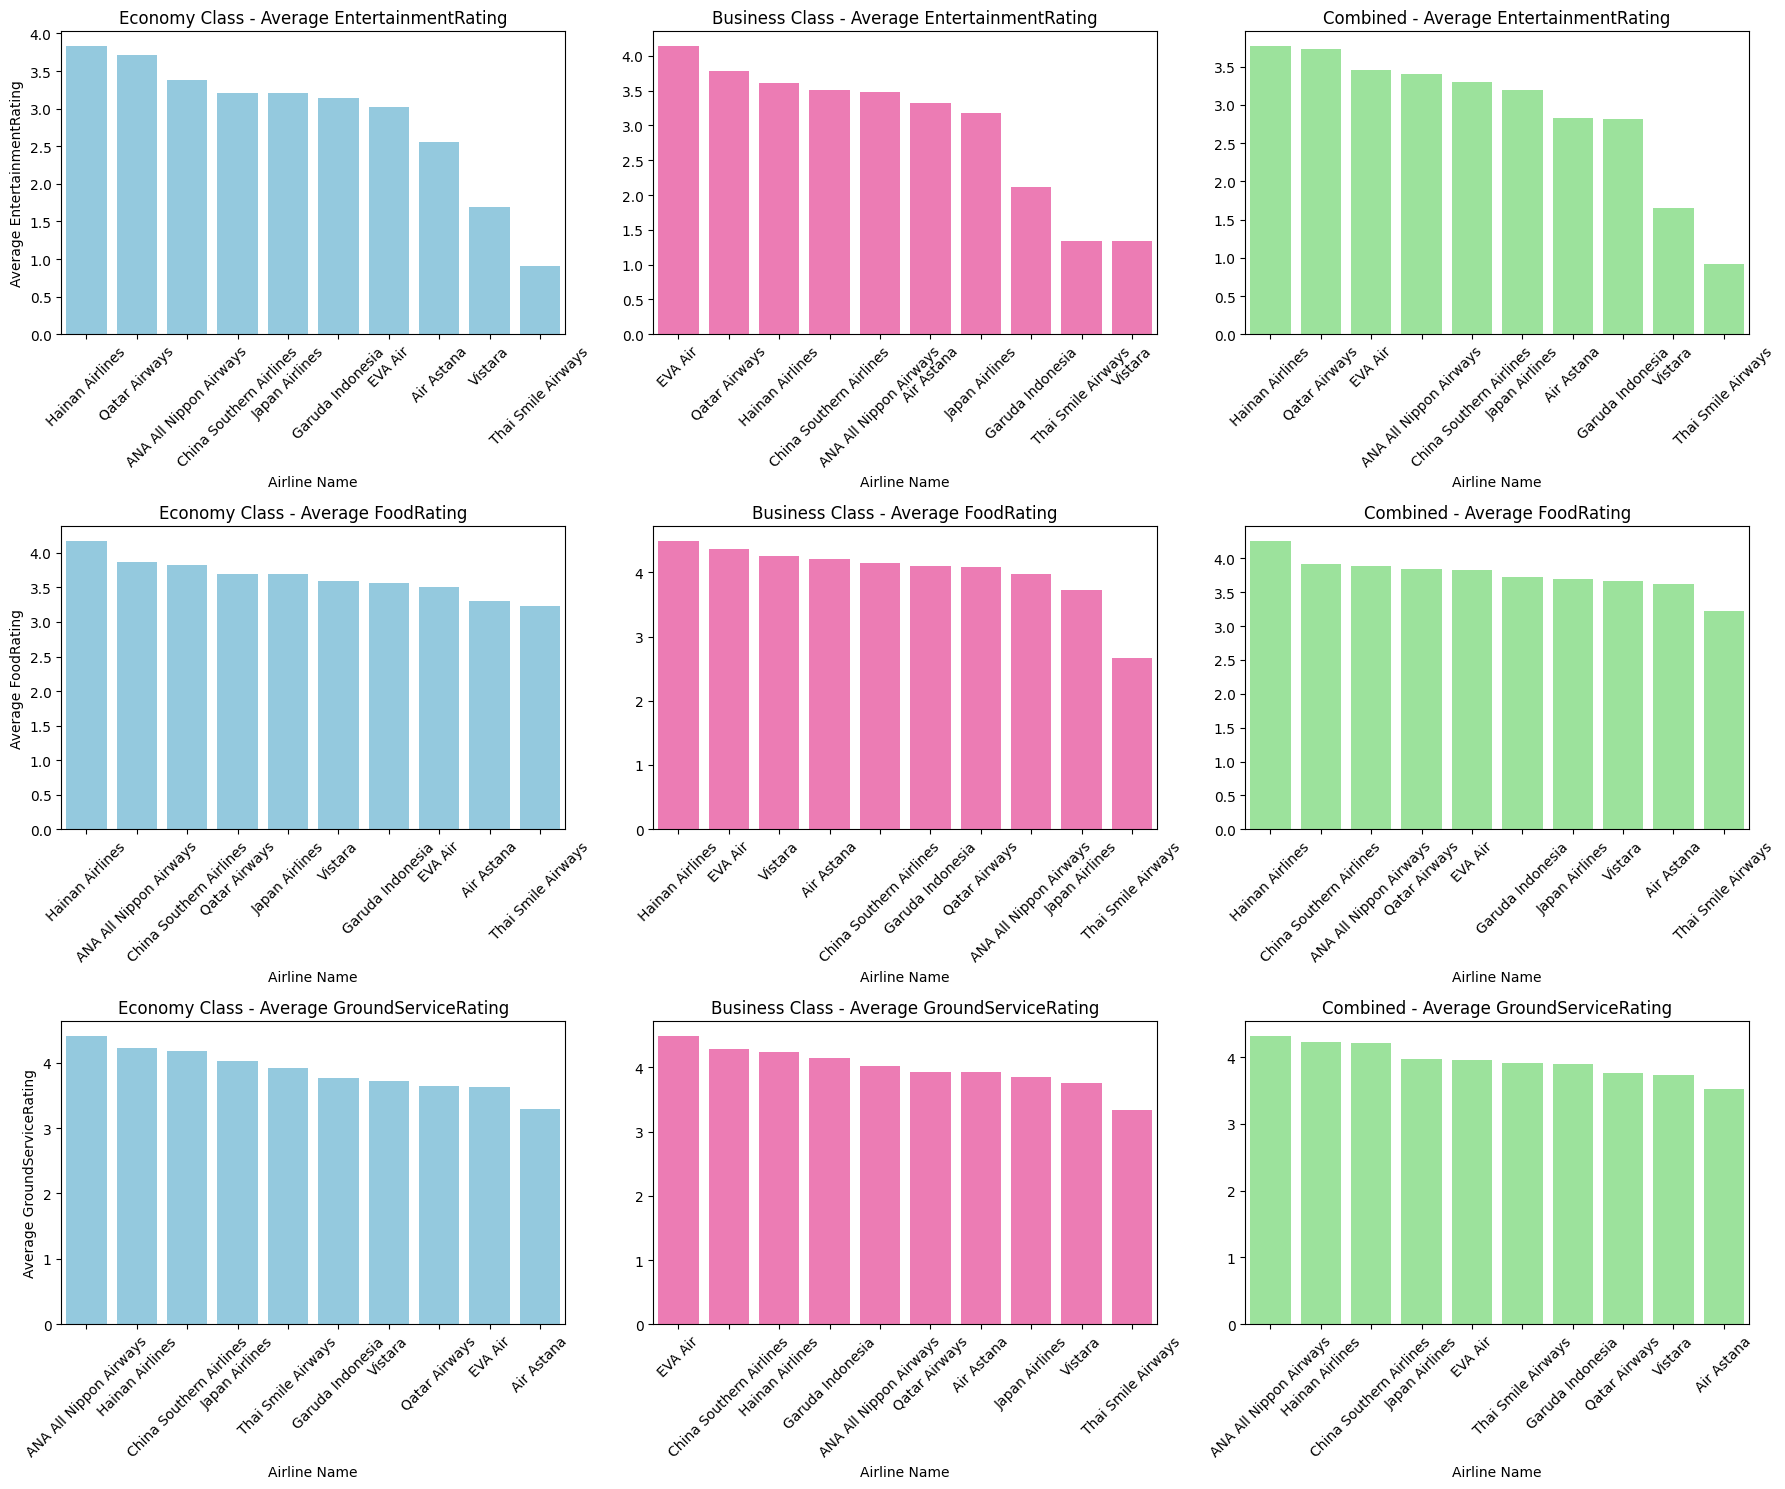

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 airlines based on overall average rating
top_10_overall_airlines = sample_df.groupby('AirlineName')['OverallScore'].mean().sort_values(ascending=False).head(10).index.tolist()

# Filter data for top 10 airlines
top_airlines_sample_df = sample_df[sample_df['AirlineName'].isin(top_10_overall_airlines)]

# Define rating categories
rating_categories = ['EntertainmentRating', 'FoodRating', 'GroundServiceRating']

# Create subplots for each rating category
fig, axes = plt.subplots(len(rating_categories), 3, figsize=(18, 5 * len(rating_categories)))

for i, category in enumerate(rating_categories):
    # Plot for Economy Class
    economy_sample_df = top_airlines_sample_df[top_airlines_sample_df['CabinType'] == 'Economy Class']
    avg_ratings_economy = economy_sample_df.groupby('AirlineName')[category].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=avg_ratings_economy.index, y=avg_ratings_economy.values, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Economy Class - Average {category}')
    axes[i, 0].set_xlabel('Airline Name')
    axes[i, 0].set_ylabel(f'Average {category}')
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Plot for Business Class
    business_sample_df = top_airlines_sample_df[top_airlines_sample_df['CabinType'] == 'Business Class']
    avg_ratings_business = business_sample_df.groupby('AirlineName')[category].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=avg_ratings_business.index, y=avg_ratings_business.values, ax=axes[i, 1], color='hotpink')
    axes[i, 1].set_title(f'Business Class - Average {category}')
    axes[i, 1].set_xlabel('Airline Name')
    axes[i, 1].set_ylabel('')
    axes[i, 1].tick_params(axis='x', rotation=45)

    # Plot for Combined Cabin Types
    avg_ratings_combined = top_airlines_sample_df.groupby('AirlineName')[category].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=avg_ratings_combined.index, y=avg_ratings_combined.values, ax=axes[i, 2], color='lightgreen')
    axes[i, 2].set_title(f'Combined - Average {category}')
    axes[i, 2].set_xlabel('Airline Name')
    axes[i, 2].set_ylabel('')
    axes[i, 2].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

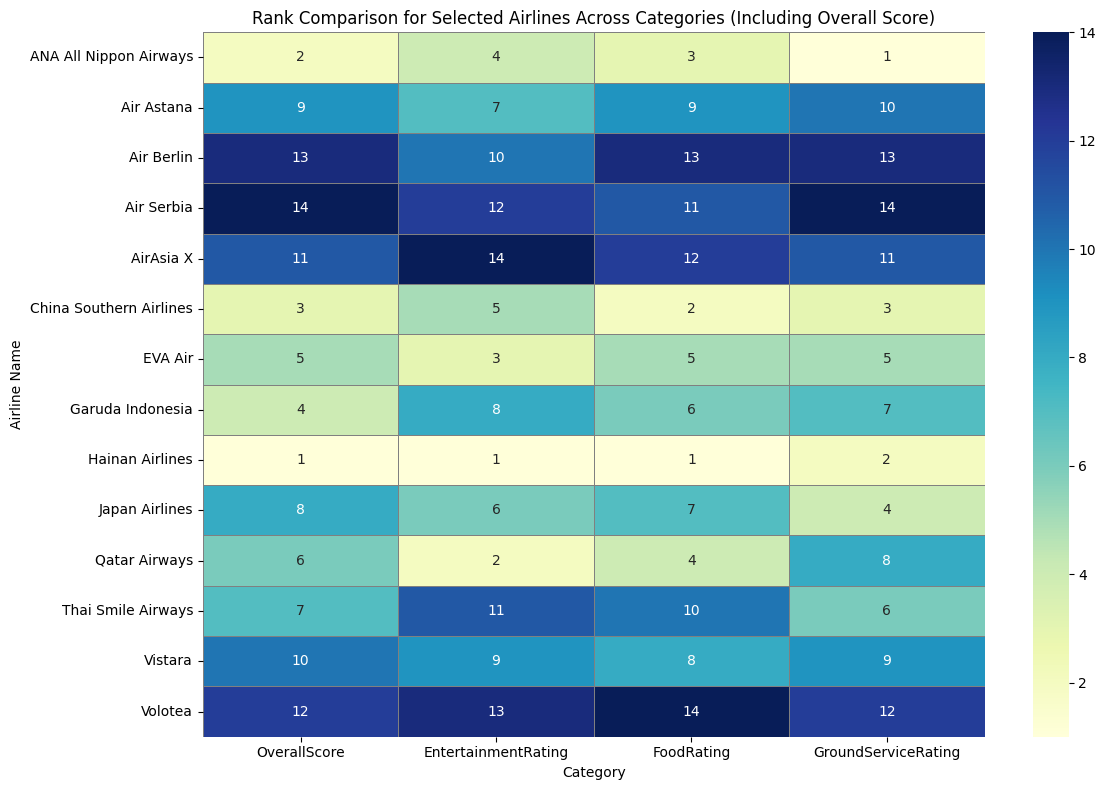

In [6]:
# Define the list of airlines to include in the heatmap
selected_airlines = [
    'Hainan Airlines', 'ANA All Nippon Airways', 'China Southern Airlines',
    'Japan Airlines', 'Garuda Indonesia', 'EVA Air', 'Qatar Airways',
    'Thai Smile Airways', 'Vistara', 'Air Astana', 'Volotea',
    'AirAsia X', 'Air Berlin', 'Air Serbia'
]

# Compute average scores for the selected airlines across relevant categories, including OverallScore
category_avgs = sample_df[sample_df['AirlineName'].isin(selected_airlines)].groupby('AirlineName')[['OverallScore', 'EntertainmentRating', 'FoodRating', 'GroundServiceRating']].mean()

# Rank only within the selected airlines for this heatmap
ranked_selected = category_avgs.rank(ascending=False)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ranked_selected, annot=True, cmap='YlGnBu', fmt='.0f', linewidths=0.5, linecolor='gray')
plt.title('Rank Comparison for Selected Airlines Across Categories (Including Overall Score)')
plt.xlabel('Category')
plt.ylabel('Airline Name')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Comparison of Overall Ratings vs. Entertainment, Food and Ground Services Ratings**

---



A comparison of the top 10 airlines by overall rating with those ranked by entertainment, food, and ground service reveals alignment for some airlines, but key differences for others. Hainan Airlines, ANA All Nippon Airways, and China Southern Airlines consistently appear in all rankings, indicating balanced service quality across touchpoints. However, Qatar Airways, despite not making the overall top 10, features prominently in entertainment and food ratings, suggesting high quality service in specific areas but potentially lower satisfaction in others, such as seat comfort or value. Conversely, Volotea ranks highly in Business Class overall ratings but does not appear in any top 10 service specific visualizations.

### **2.2.3 Possible Reasons for Variations**

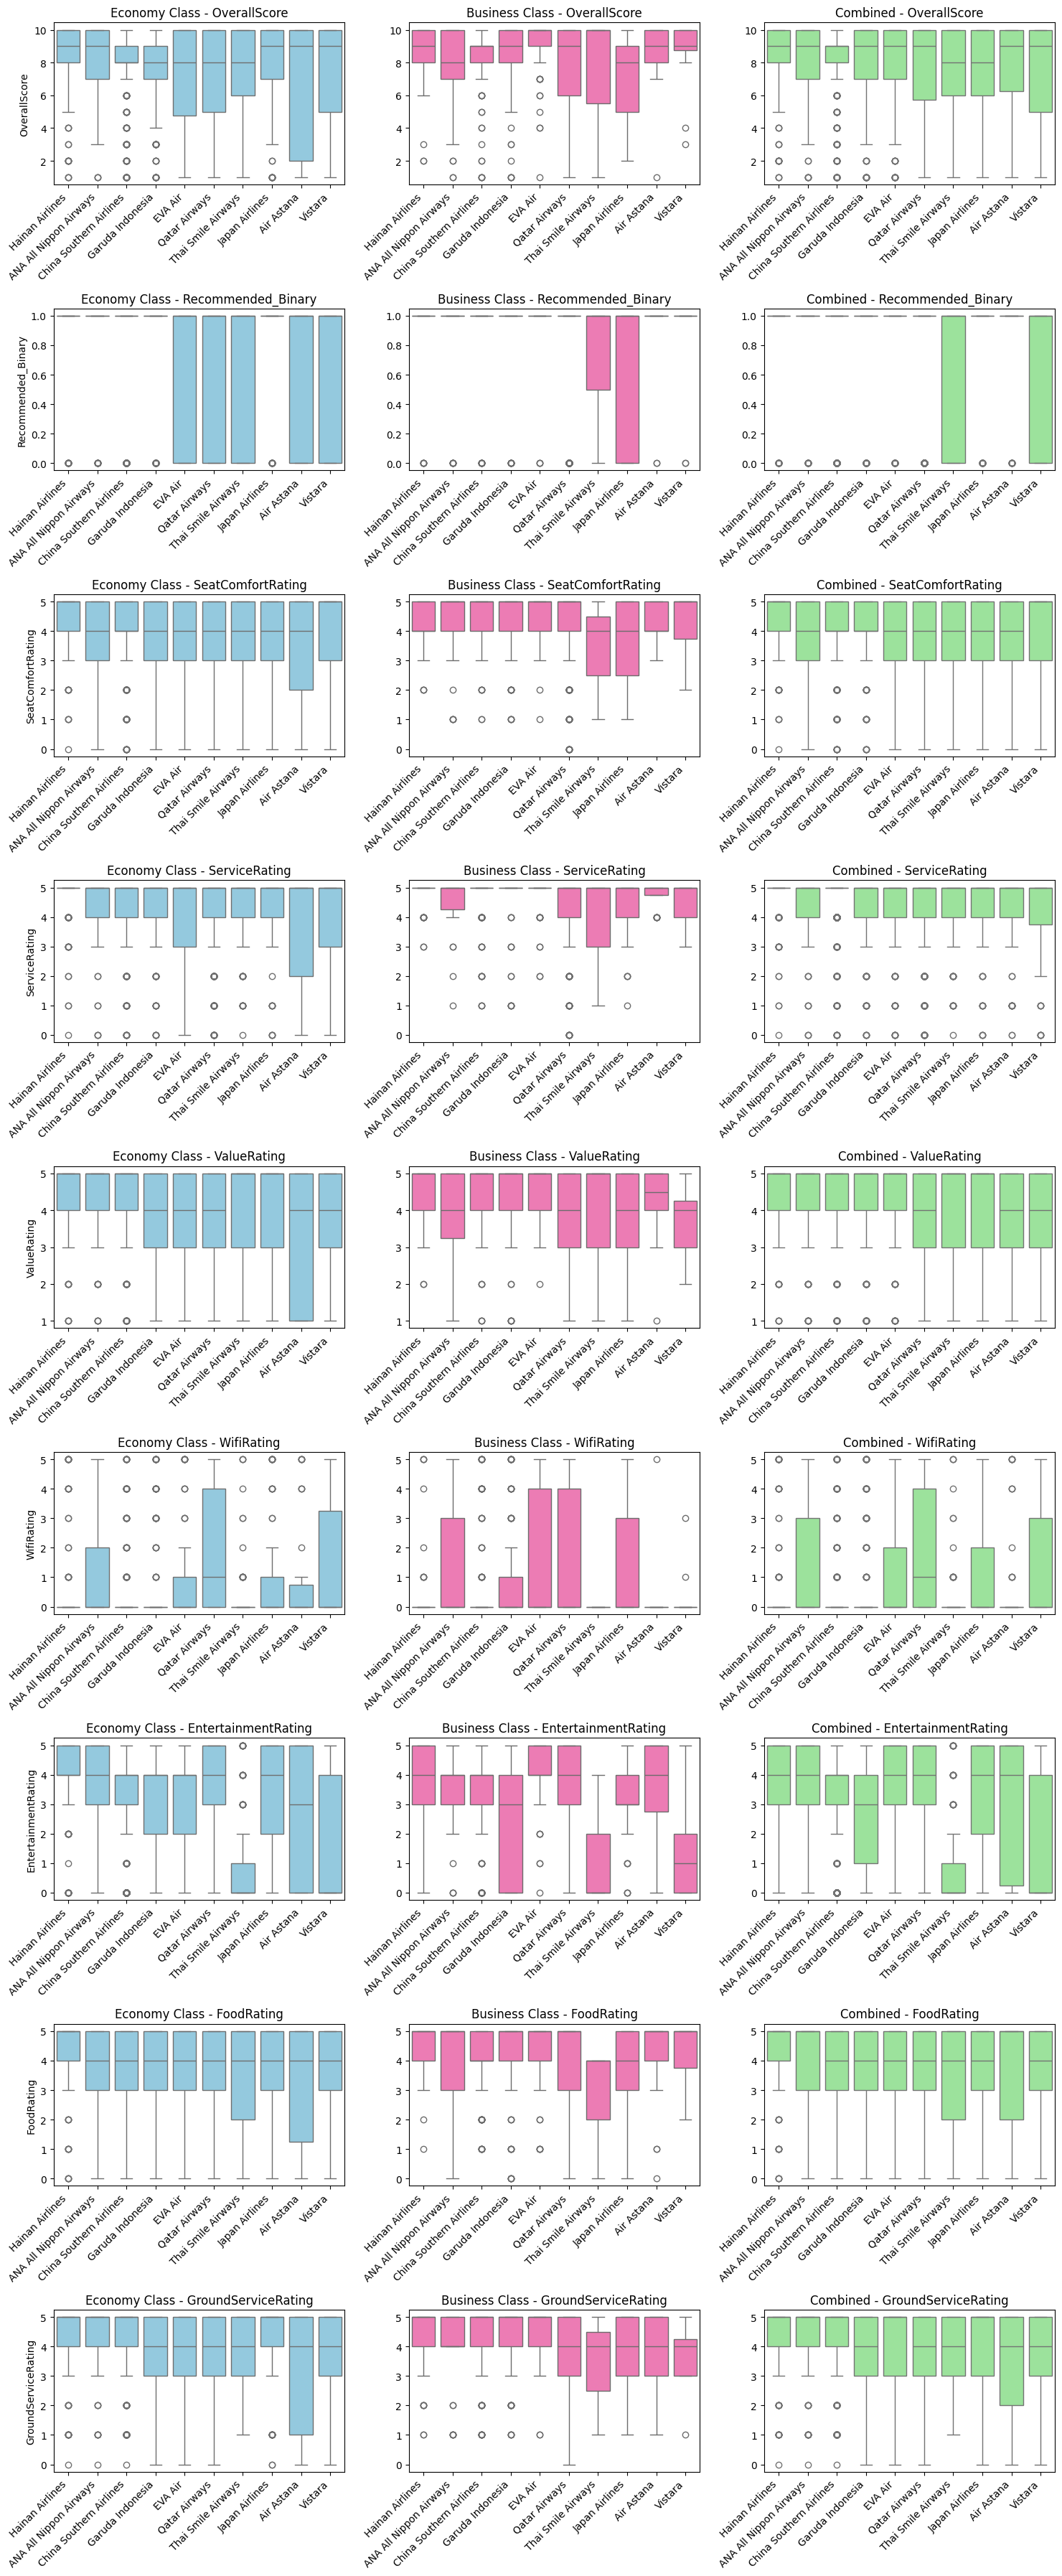

In [7]:
import numpy as np

# Convert 'yes'/'no' in 'Recommended' column to binary (1/0)
sample_df['Recommended_Binary'] = sample_df['Recommended'].str.lower().map({'yes': 1, 'no': 0})

# Identify the top 10 airlines based on overall average rating
top_10_overall_airlines = sample_df.groupby('AirlineName')['OverallScore'].mean().sort_values(ascending=False).head(10).index.tolist()

# Filter the dataframe to include only reviews from the top 10 airlines
top_airlines_sample_df = sample_df[sample_df['AirlineName'].isin(top_10_overall_airlines)]

# Define rating categories to plot
rating_categories = ['OverallScore', 'Recommended_Binary', 'SeatComfortRating', 'ServiceRating', 'ValueRating', 'WifiRating']

# Add 'EntertainmentRating', 'FoodRating', and 'GroundServiceRating' from previous plots
rating_categories.extend(['EntertainmentRating', 'FoodRating', 'GroundServiceRating'])
cabin_types = ['Economy Class', 'Business Class']
colors = ['skyblue', 'hotpink', 'lightgreen']


# Create a figure with subplots for each rating category and cabin type/combined
fig, axes = plt.subplots(len(rating_categories), 3, figsize=(15, 4 * len(rating_categories)))

# Filter data for each cabin type once before the loop
economy_sample_df_filtered = top_airlines_sample_df[top_airlines_sample_df['CabinType'] == 'Economy Class']
business_sample_df_filtered = top_airlines_sample_df[top_airlines_sample_df['CabinType'] == 'Business Class']

for i, category in enumerate(rating_categories):
    # Plot for Economy Class
    sns.boxplot(x='AirlineName', y=category, data=economy_sample_df_filtered, order=top_10_overall_airlines, ax=axes[i, 0], color=colors[0])
    axes[i, 0].set_title(f'Economy Class - {category}')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel(category)
    axes[i, 0].set_xticks(np.arange(len(top_10_overall_airlines)))
    axes[i, 0].set_xticklabels(top_10_overall_airlines, rotation=45, ha='right')

    # Plot for Business Class
    sns.boxplot(x='AirlineName', y=category, data=business_sample_df_filtered, order=top_10_overall_airlines, ax=axes[i, 1], color=colors[1])
    axes[i, 1].set_title(f'Business Class - {category}')
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('')
    axes[i, 1].set_xticks(np.arange(len(top_10_overall_airlines)))
    axes[i, 1].set_xticklabels(top_10_overall_airlines, rotation=45, ha='right')

    # Plot for Combined Cabin Types
    sns.boxplot(x='AirlineName', y=category, data=top_airlines_sample_df, order=top_10_overall_airlines, ax=axes[i, 2], color=colors[2])
    axes[i, 2].set_title(f'Combined - {category}')
    axes[i, 2].set_xlabel('')
    axes[i, 2].set_ylabel('')
    axes[i, 2].set_xticks(np.arange(len(top_10_overall_airlines)))
    axes[i, 2].set_xticklabels(top_10_overall_airlines, rotation=45, ha='right')


plt.tight_layout()
plt.show()


**Variability in Ranking based on Services**

---



While overall score rankings provide a high level snapshot of airline performance, a closer look at underlying rating dimensions reveals notable inconsistencies. For instance, Qatar Airways did not feature in the top 10 for overall scores, yet consistently scored high in specific service categories like entertainment and seat comfort, particularly in Business Class. This suggests that while certain aspects of their service are strong, the overall experience may be hindered by weaker areas such as ground services or Wi-Fi, which visibly pulled down their combined performance.

On the other hand, Volotea, which was among the top ranked Business Class airlines by overall score, is absent from most service specific top 10 lists. This implies their high customer satisfaction may be influenced by non categorical factors, perhaps competitive pricing, route availability, or punctuality which are not directly captured in the provided service metrics (Baker et al., 2013).

Boxplots across multiple dimensions show a wide distribution of scores even among top performers. Thai Smile Airways, for example, has high median scores but also displays a broader spread and more outliers in several categories like Wi-Fi and entertainment, especially in Economy Class  (Loo & Leung, 2020). This variability may indicate inconsistency in service delivery or differences in equipment across aircraft models or routes.

Furthermore, customer recommendation metrics reveal that even airlines with strong overall scores, like ANA All Nippon Airways, occasionally receive non recommendations, possibly due to isolated poor experiences or unmet expectations. Conversely, Japan Airlines and Vistara received consistently high recommendation scores in Business Class, reinforcing that perceived value often goes beyond raw numeric ratings.

### **Other Reasons**

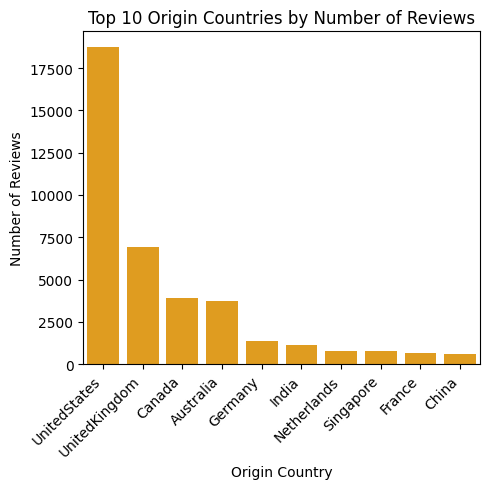

In [8]:
# Get the count of reviews per origin country
country_counts = sample_df['OriginCountry'].value_counts()

# Select the top N countries to avoid cluttering the plot
top_n_countries = 10
plt.figure(figsize=(5, 5))
sns.barplot(x=country_counts.index[:top_n_countries], y=country_counts.values[:top_n_countries], color='orange')
plt.title(f'Top {top_n_countries} Origin Countries by Number of Reviews')
plt.xlabel('Origin Country')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

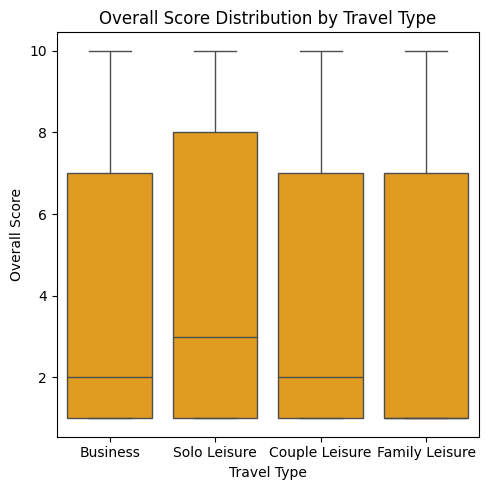

In [9]:
# Create a box plot to show the distribution of OverallScore by TravelType
plt.figure(figsize=(5,5))
sns.boxplot(x='TravelType', y='OverallScore', data=sample_df, color='orange')
plt.title('Overall Score Distribution by Travel Type')
plt.xlabel('Travel Type')
plt.ylabel('Overall Score')
plt.tight_layout()
plt.show()

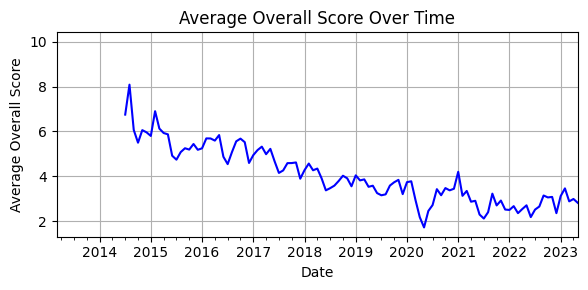

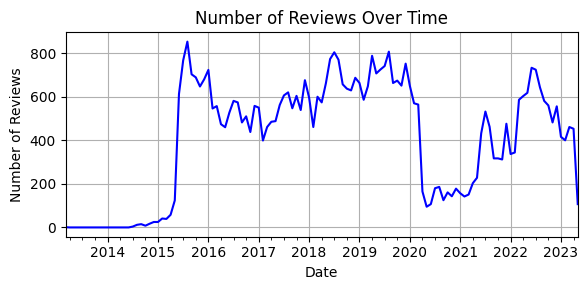

In [10]:
# Convert 'DateFlown' to datetime objects
sample_df['DateFlown'] = pd.to_datetime(sample_df['DateFlown'], format='%b-%y', errors='coerce')

# Drop rows with invalid dates
sample_df.dropna(subset=['DateFlown'], inplace=True)

# Group by month and year and calculate the average overall score
monthly_avg_score = sample_df.groupby(pd.Grouper(key='DateFlown', freq='MS'))['OverallScore'].mean()

# Plot the average overall score over time
plt.figure(figsize=(6,3))
monthly_avg_score.plot(color='blue')
plt.title('Average Overall Score Over Time')
plt.xlabel('Date')
plt.ylabel('Average Overall Score')
plt.grid(True)
plt.tight_layout()
plt.show()

# Group by month and year and count the number of reviews
monthly_review_count = sample_df.groupby(pd.Grouper(key='DateFlown', freq='MS')).size()

# Plot the number of reviews over time
plt.figure(figsize=(6,3))
monthly_review_count.plot(color='blue')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

**Other Potential Factors Behind Rating Variations**

---



Beyond service quality, several external factors may contribute to variation in airline scores. Traveller origin appears influential, with the United States and United Kingdom generating the majority of reviews, possibly skewing perception toward Western service expectations (Li et al., 2021). Travel purpose also matters, leisure travellers, especially solo, gave higher scores compared to business travellers, who may hold stricter standards (Aksoy et al., 2020). Additionally, average scores have declined steadily since 2015, potentially influenced by rising airfare dissatisfaction, pandemic related service disruptions, or shifting customer expectations. These elements highlight how broader contextual factors, not just airline performance can significantly shape customer sentiment and ratings over time.

### **2.2.4 Presence of Qantas and Jetstar Airways in Top 10 Overall Airline Rankings**

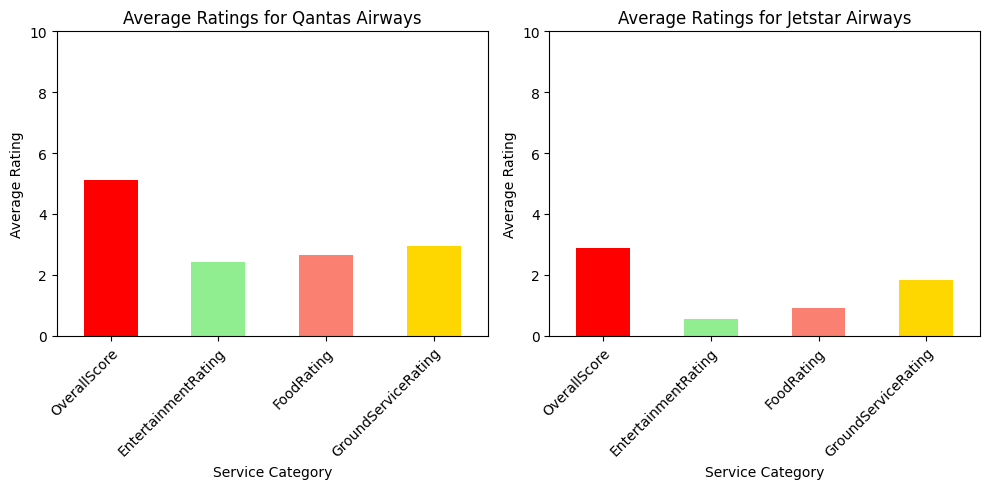

In [11]:
# Filter data for Qantas Airways and Jetstar Airways
qantas_jetstar_sample_df = sample_df[sample_df['AirlineName'].isin(['Qantas Airways', 'Jetstar Airways'])]

# Calculate average ratings for the relevant categories
avg_ratings_qantas_jetstar = qantas_jetstar_sample_df.groupby('AirlineName')[['OverallScore', 'EntertainmentRating', 'FoodRating', 'GroundServiceRating']].mean()

# Transpose the dataframe for easier plotting
avg_ratings_qantas_jetstar_T = avg_ratings_qantas_jetstar.T

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot for Qantas Airways in the first subplot
avg_ratings_qantas_jetstar_T['Qantas Airways'].plot(kind='bar', ax=axes[0], color=['red', 'lightgreen', 'salmon', 'gold'])
axes[0].set_title('Average Ratings for Qantas Airways')
axes[0].set_xlabel('Service Category')
axes[0].set_ylabel('Average Rating')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xticklabels(avg_ratings_qantas_jetstar_T.index, rotation=45, ha='right', rotation_mode='anchor')
axes[0].set_ylim(0, 10)

# Plot for Jetstar Airways in the second subplot
avg_ratings_qantas_jetstar_T['Jetstar Airways'].plot(kind='bar', ax=axes[1], color=['red', 'lightgreen', 'salmon', 'gold'])
axes[1].set_title('Average Ratings for Jetstar Airways')
axes[1].set_xlabel('Service Category')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xticklabels(avg_ratings_qantas_jetstar_T.index, rotation=45, ha='right', rotation_mode='anchor')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

**Presence of Qantas and Jetstar in Top Rankings**

---



Neither Qantas Airways nor Jetstar Airways appear in the previously identified top 10 rankings for any service category or cabin type. A comparison of their average service ratings with those of top performing airlines reveals a notable performance gap.

Jetstar Airways performs significantly below the benchmark in all service categories. The airline's OverallScore averages below 3, while both EntertainmentRating and FoodRating remain near or below 1. These figures reflect consistently poor customer satisfaction across multiple service dimensions. Although GroundServiceRating is relatively higher, it still falls short of the standards set by leading carriers such as Hainan Airlines and ANA.

Qantas Airways displays moderately better performance, with an OverallScore close to 5 and other service ratings such as food, entertainment, and ground service falling between 2.5 and 3. Despite being an improvement over Jetstar, these ratings remain well below the averages observed among top tier airlines. For context, leading carriers often record OverallScores above 8, alongside strong service specific scores exceeding 4 or 5 across various categories.

### **2.2.5 Recommendation Status of Qantas and Jetstar Airways Among Passengers**

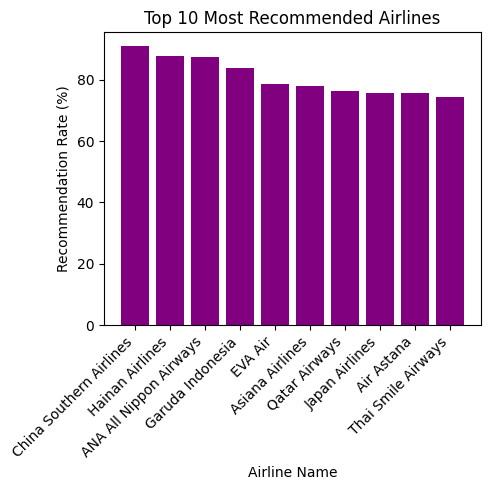

In [12]:
# Convert 'yes'/'no' in 'Recommended' column to binary (1/0)
sample_df['Recommended_Binary'] = sample_df['Recommended'].str.lower().map({'yes': 1, 'no': 0})

# Calculate recommendation rate per airline (%)
recommendation_rate = sample_df.groupby('AirlineName')['Recommended_Binary'].mean() * 100

# Get top 10 airlines by recommendation rate
top_10_recommended_airlines = recommendation_rate.sort_values(ascending=False).head(10)

# Prepare data for plot
airlines = top_10_recommended_airlines.index.tolist()
recommendation_rates = top_10_recommended_airlines.values

# Plot
plt.figure(figsize=(5,5))
plt.bar(airlines, recommendation_rates, color='purple')
plt.title('Top 10 Most Recommended Airlines')
plt.xlabel('Airline Name')
plt.ylabel('Recommendation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


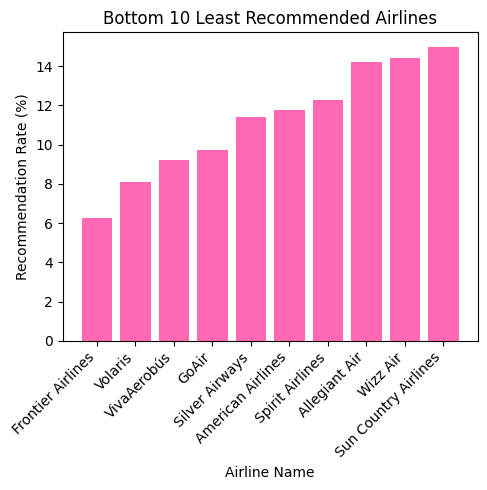

In [13]:
# Recommendation rate per airline
recommendation_counts = sample_df.groupby('AirlineName')['Recommended'].value_counts(normalize=True).unstack()
recommendation_rate = recommendation_counts['yes'] * 100

# Bottom 10 recommended airlines
bottom_10_recommended_airlines = recommendation_rate.sort_values(ascending=True).head(10)

# Prepare for plot
airlines = bottom_10_recommended_airlines.index.tolist()
recommendation_rates = bottom_10_recommended_airlines.values

# Plot
plt.figure(figsize=(5, 5))
plt.bar(airlines, recommendation_rates, color='hotpink')
plt.title('Bottom 10 Least Recommended Airlines')
plt.xlabel('Airline Name')
plt.ylabel('Recommendation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Recommendation Ranking for Qantas and Jetstar**

---



Based on the recommendation rates analysis, neither Qantas Airways nor Jetstar Airways appears in the list of the top 10 most recommended airlines. More importantly, they are also absent from the bottom 10 least recommended airlines. This suggests both carriers sit somewhere in the mid range in terms of customer endorsement. While this positioning may indicate average service perception, it also reflects a missed opportunity for either airline to differentiate through exceptional customer experiences. For a major Australian airline like Qantas, this neutrality could raise strategic concerns around brand loyalty and competitive advantage in the regional market.

#**2.3 PART B**

### **2.3.1 Trend Analysis of Overall Passenger Ratings for Qantas Airways vs Top 5 Airlines Over Times**

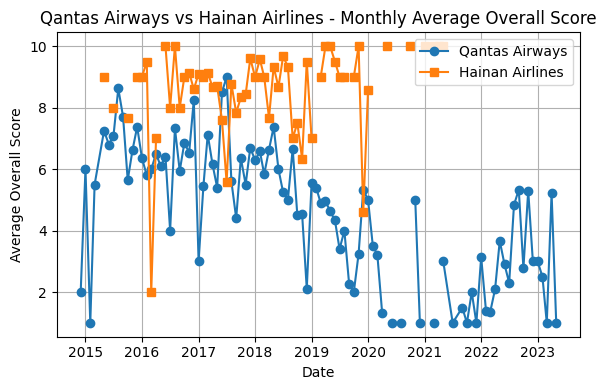

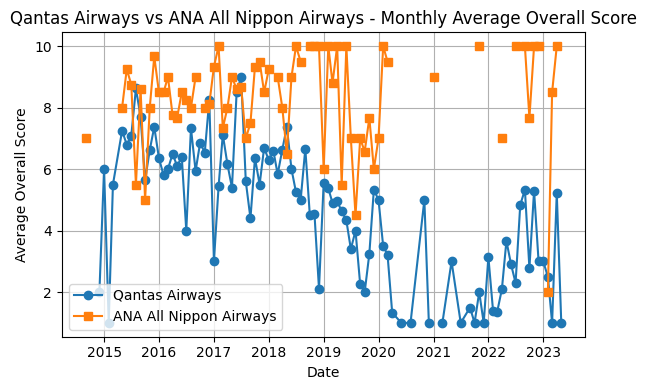

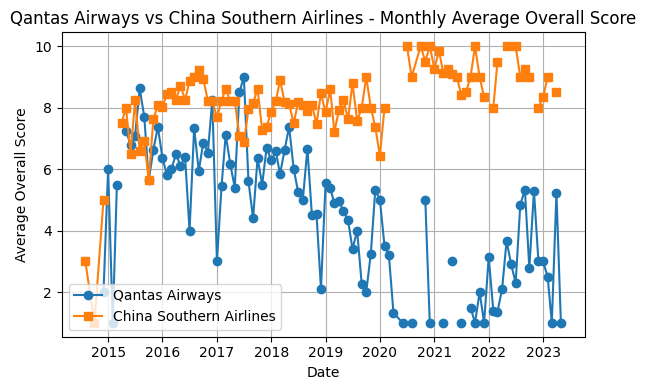

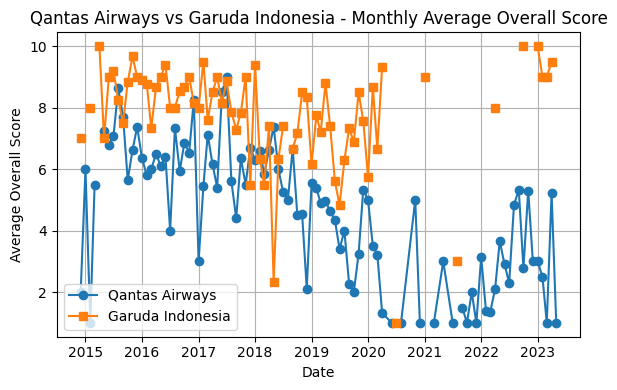

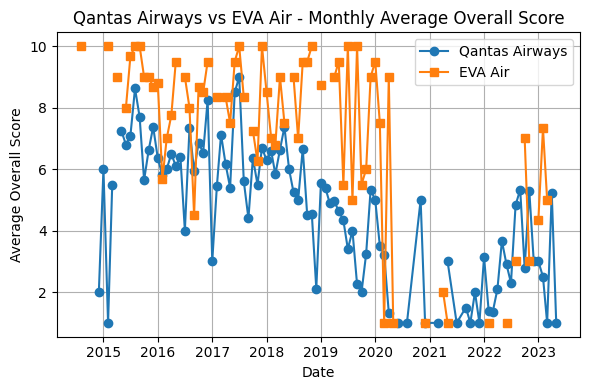

In [14]:
# Convert 'DateFlown' to datetime format
sample_df['DateFlown'] = pd.to_datetime(sample_df['DateFlown'], format='%b-%y', errors='coerce')

# Drop rows with invalid dates
sample_df.dropna(subset=['DateFlown'], inplace=True)

# Compute average overall scores by airline
average_scores = sample_df.groupby('AirlineName')['OverallScore'].mean()

# Identify top 5 airlines by average score (excluding Qantas for now)
top_5_airlines = average_scores.drop('Qantas Airways', errors='ignore').sort_values(ascending=False).head(5).index.tolist()

# Loop through each top 5 airline and compare with Qantas
for airline in top_5_airlines:
    # Filter data for current airline and Qantas
    subset_sample_df = sample_df[sample_df['AirlineName'].isin(['Qantas Airways', airline])]

    # Group by month and airline, compute average score
    monthly_scores = subset_sample_df.groupby([pd.Grouper(key='DateFlown', freq='MS'), 'AirlineName'])['OverallScore'].mean().unstack()

    # Plot the line chart
    plt.figure(figsize=(6, 4)) # Adjusted figure size for better readability
    if 'Qantas Airways' in monthly_scores.columns:
        plt.plot(monthly_scores.index, monthly_scores['Qantas Airways'], marker='o', label='Qantas Airways')
    if airline in monthly_scores.columns:
        plt.plot(monthly_scores.index, monthly_scores[airline], marker='s', label=airline)

    plt.title(f'Qantas Airways vs {airline} - Monthly Average Overall Score')
    plt.xlabel('Date')
    plt.ylabel('Average Overall Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Time Series Comparison of Qantas Airways and Top 5 Airlines**

---



A longitudinal comparison of monthly average overall scores reveals a clear divergence between Qantas Airways and the top five rated airlines Hainan Airlines, ANA All Nippon Airways, China Southern Airlines, Garuda Indonesia, and EVA Air. While Qantas maintained relatively stable scores between 2015 and 2018, its ratings began to decline sharply from 2019 onward. By 2020, during the early phase of the COVID-19 pandemic, Qantas experienced a sustained drop in average scores, frequently falling below 3.0. Although there was a partial recovery in 2022, it failed to return to pre-pandemic levels.

In contrast, the top five airlines displayed greater score consistency and resilience. Most maintained high average ratings above 7.0 throughout the period, with only minor fluctuations. This suggests stronger service continuity and customer satisfaction despite global disruptions.

The decline in Qantas’ ratings could be attributed to operational cutbacks, reduced staffing, and service limitations during and after the pandemic factors widely reported across the aviation industry. Additionally, increased domestic travel pressure may have strained service quality, negatively affecting customer perceptions.



---



---



# **3.SENTIMENT ANALYSIS**

#**3.1 PART C**

### **3.1.1 Overall Airline Customer Positive Sentiments**

In [15]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

# Function to calculate overall sentiment score for a review
def overall_sentiment(review_text):
    try:
        scores = sid.polarity_scores(str(review_text))
        return scores['compound']
    except:
        return 0

# Apply the function to the 'Review' column to get overall sentiment scores for each review
sample_df['SentimentScore'] = sample_df['Review'].apply(overall_sentiment)

# Calculate the average sentiment score for each airline
avg_sentiment = sample_df.groupby('AirlineName')['SentimentScore'].mean().sort_values(ascending=False)

# Identify the airline with the most positive sentiment
most_positive_airline = avg_sentiment.index[0]
most_positive_score = avg_sentiment.iloc[0]

print("Average Sentiment Score by Airline:")
display(avg_sentiment)

print(f"\nAirline with the most positive sentiment: {most_positive_airline} (Average Sentiment Score: {most_positive_score:.4f})")

# Display the top 10 airlines by sentiment score
top_10_sentiment_airlines = avg_sentiment.head(10)
print("\nTop 10 Airlines by Average Sentiment Score:")
display(top_10_sentiment_airlines)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Average Sentiment Score by Airline:


,SentimentScore
AirlineName,
Hainan Airlines,0.790183
China Southern Airlines,0.728352
ANA All Nippon Airways,0.699724
Garuda Indonesia,0.645934
EVA Air,0.614916
...,...
Breeze Airways,-0.391914
Frontier Airlines,-0.413353
GoAir,-0.434813



Airline with the most positive sentiment: Hainan Airlines (Average Sentiment Score: 0.7902)

Top 10 Airlines by Average Sentiment Score:


,SentimentScore
AirlineName,
Hainan Airlines,0.790183
China Southern Airlines,0.728352
ANA All Nippon Airways,0.699724
Garuda Indonesia,0.645934
EVA Air,0.614916
Japan Airlines,0.585597
Asiana Airlines,0.581746
Qatar Airways,0.577523
Korean Air,0.548562


**Positive Sentiment Analysis Across Airlines**

---



Sentiment analysis of customer reviews reveals clear distinctions in how passengers perceive different airlines. Hainan Airlines received the highest average sentiment score of 0.79, indicating overwhelmingly positive sentiment from its customer base. This result aligns with Hainan’s consistently high ratings across service dimensions, suggesting a strong, holistic brand experience. Following closely are China Southern Airlines (0.73) and ANA All Nippon Airways (0.70), both of which also appear in the top overall ratings, reinforcing the link between perceived service quality and emotional response in reviews.

Other airlines such as Garuda Indonesia and EVA Air also performed strongly, maintaining sentiment scores above 0.6. At the lower end of the spectrum, carriers like Silver Airways, Volaris, and GoAir received negative average sentiment scores, indicating significant customer dissatisfaction.


#**3.2 PART D**

### **3.2.1 Airlines with Positive Sentiment for Economy and Business Class Service/s**

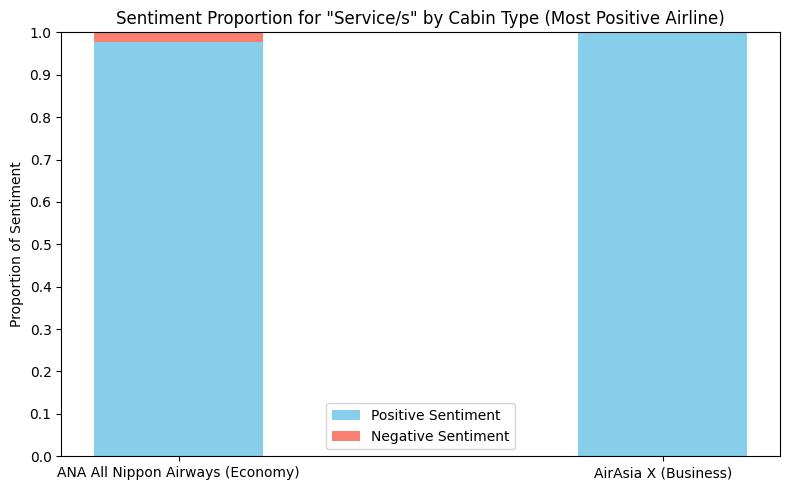

In [16]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from statistics import mean
import numpy as np

sid = SentimentIntensityAnalyzer()

# Define a function to calculate sentiment proportion for a given aspect
def aspect_sentiment_for_subset(subset_df, aspect):
    # Filter reviews that contain the aspect
    aspect_reviews = subset_df[
        subset_df['Review'].str.contains(aspect, case=False, na=False)
    ].copy()

    if aspect_reviews.empty:
        return 0, 0

    # Calculate sentiment scores for the filtered reviews
    aspect_reviews['SentimentScore'] = aspect_reviews['Review'].apply(lambda x: sid.polarity_scores(str(x))['compound'])

    # Calculate positive and negative proportions
    positive_proportion = (aspect_reviews['SentimentScore'] > 0).mean()
    negative_proportion = (aspect_reviews['SentimentScore'] < 0).mean()

    return positive_proportion, negative_proportion


# Sentiment analysis to get the positive and negative proportions for 'service/s'
aspects = ['service','services']
cabin_types = ['Economy Class', 'Business Class']

sentiment_data_for_plot = {}

for cabin_type in cabin_types:
    cabin_df = sample_df[sample_df['CabinType'] == cabin_type].copy()

    airline_sentiment = {}
    for airline in cabin_df['AirlineName'].unique():
        airline_df = cabin_df[cabin_df['AirlineName'] == airline]
        sentiment_scores = []
        for aspect in aspects:
            sentiment_scores.append(aspect_sentiment_for_subset(airline_df, aspect))

        # Calculate the average positive and negative proportions across the aspects for this airline
        avg_positive_proportion = mean([score[0] for score in sentiment_scores])
        avg_negative_proportion = mean([score[1] for score in sentiment_scores])
        airline_sentiment[airline] = {'positive': avg_positive_proportion, 'negative': avg_negative_proportion}

    # Find the airline with the most positive sentiment for the current cabin type
    most_positive_airline = max(airline_sentiment, key=lambda k: airline_sentiment[k]['positive'])
    sentiment_data_for_plot[cabin_type] = {'airline': most_positive_airline,
                                           'positive': airline_sentiment[most_positive_airline]['positive'],
                                           'negative': airline_sentiment[most_positive_airline]['negative']}

# Prepare data for plotting
airlines_for_plot = [sentiment_data_for_plot['Economy Class']['airline'],
                     sentiment_data_for_plot['Business Class']['airline']]
positive_proportions = [sentiment_data_for_plot['Economy Class']['positive'],
                        sentiment_data_for_plot['Business Class']['positive']]
negative_proportions = [sentiment_data_for_plot['Economy Class']['negative'],
                        sentiment_data_for_plot['Business Class']['negative']]

# Plotting the sentiment proportions
ind = np.arange(len(airlines_for_plot))
width = 0.35

pyplot.figure(figsize=(8, 5))
p1 = pyplot.bar(ind, positive_proportions, width, color='skyblue', label='Positive Sentiment')
p2 = pyplot.bar(ind, negative_proportions, width, bottom=positive_proportions, color='salmon', label='Negative Sentiment')

pyplot.ylabel('Proportion of Sentiment')
pyplot.title('Sentiment Proportion for "Service/s" by Cabin Type (Most Positive Airline)')
pyplot.xticks(ind, [f"{airlines_for_plot[0]} (Economy)", f"{airlines_for_plot[1]} (Business)"])
pyplot.yticks(np.arange(0, 1.1, 0.1))
pyplot.legend()

pyplot.tight_layout()
pyplot.show()

In [17]:
# Filter for Fiji Airways
fiji_df = sample_df[sample_df['AirlineName'] == 'Fiji Airways'].copy()

# Count reviews containing "service" or "services" (case-insensitive)
service_reviews_count_all_cabins = fiji_df[
    fiji_df['Review'].str.contains('service|services', case=False, na=False)
].shape[0]

print(f"Number of reviews for Fiji Airways containing 'service' or 'services': {service_reviews_count_all_cabins}")

#  for ANA All Nippon Airways
ana_df = sample_df[sample_df['AirlineName'] == 'ANA All Nippon Airways'].copy()

# Count reviews containing "service" or "services" (case-insensitive)
service_reviews_count_ana = ana_df[
    ana_df['Review'].str.contains('service|services', case=False, na=False)
].shape[0]

print(f"Number of reviews for ANA All Nippon Airways containing 'service' or 'services': {service_reviews_count_ana}")

Number of reviews for Fiji Airways containing 'service' or 'services': 39
Number of reviews for ANA All Nippon Airways containing 'service' or 'services': 107


In [18]:
# Filter data for ANA All Nippon Airways in Economy Class
ana_economy_df = sample_df[(sample_df['AirlineName'] == 'ANA All Nippon Airways') & (sample_df['CabinType'] == 'Economy Class')].copy()

# Filter data for Fiji Airways in Business Class
fiji_business_df = sample_df[(sample_df['AirlineName'] == 'Fiji Airways') & (sample_df['CabinType'] == 'Business Class')].copy()

# Count reviews containing "service" or "services" (case-insensitive) for ANA Economy
service_reviews_count_ana_economy = ana_economy_df[
    ana_economy_df['Review'].str.contains('service|services', case=False, na=False)
].shape[0]

# Count reviews containing "service" or "services" (case-insensitive) for Fiji Business
service_reviews_count_fiji_business = fiji_business_df[
    fiji_business_df['Review'].str.contains('service|services', case=False, na=False)
].shape[0]


print(f"Number of reviews for ANA All Nippon Airways (Economy Class) containing 'service' or 'services': {service_reviews_count_ana_economy}")
print(f"Number of reviews for Fiji Airways (Business Class) containing 'service' or 'services': {service_reviews_count_fiji_business}")

Number of reviews for ANA All Nippon Airways (Economy Class) containing 'service' or 'services': 84
Number of reviews for Fiji Airways (Business Class) containing 'service' or 'services': 7


**Sentiment Toward “Service/s” Mentions by Cabin Class**

---



A focused sentiment analysis was conducted on customer feedback specifically referencing “service” or “services,” with results segmented by cabin type. In Economy Class, ANA All Nippon Airways received the most positive sentiment, with 84 economy class reviews out of 107 total reviews. Approximately 98% of these Economy related service reviews were positive, demonstrating strong consistency in perceived service quality.

In Business Class, Fiji Airways stood out, with all seven reviews mentioning service classified as 100% positive. While the review volume is smaller as 7 business reviews out of total 39, the sentiment consistency is noteworthy and suggests exceptional service delivery in the business cabin segment.



---



---



# **4.TOPIC MODELLING**

#**4.1 PART E**

### **4.1.1 Data Cleaning**

In [19]:
from nltk.stem import PorterStemmer
import re

porter = PorterStemmer()
documents = sample_df['Review']
Cleaned_doc = []
for r in range(len(documents)):
    review = documents.iloc[r]
    try:
        # Remove everything except alphabets
        review = re.sub('[^A-Za-z.,]', ' ', str(review))

        # Make all text lowercase
        review = review.lower()

        # Apply tokenization
        Tokens = review.split()

        # Remove short words
        Filtered_token = [w for w in Tokens if len(w) > 6]
        review = ' '.join(Filtered_token)
    except:
        continue
    #Save cleaned text
    Cleaned_doc.append(review)
    print('-[Review Text]: ', review)


Streaming output truncated to the last 5000 lines.
-[Review Text]:  husband boarded laguardia layover delayed seemingly connecting flight. another informed cancelled weather. proceeded another refusing finally thought proceeded longest customer service already boarded checked luggage without knowledge. whether because luggage houston husband airline handedly incompetent customers believe american airlines handled warning yourself
-[Review Text]:  heathrow december economy comfortable entertainment economy service attitude excellent. breakfast probably emirates.
-[Review Text]:  sacramento edmonton portland seattle. airline portland connecting seattle cancelled meaning edmonton. waiting representative. helpful because overnight vancouver different flight. traveling luggage vancouver assured delayed baggage luggage airlines airlines minutes scolded because greatful accommodated switched flights. cancelled exactly portland vancouver somewhere edmonton edmonton stopping someone tomorrow ba

**Removing Stop Words**

In [20]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Remove Stop Words
Cleaned_doc_no_stopwords = []
for r in range(len(Cleaned_doc)):
    each_item = []
    for t in Cleaned_doc[r].split():
        if t not in stop_words:
             each_item.append(t)
    cleaned_text = ' '.join(each_item)
    Cleaned_doc_no_stopwords.append(cleaned_text)
    print('-[Cleaned Text]: ', cleaned_text)


-[Cleaned Text]:  frequent traveler experience orleans antonio atlanta. courteous professional. aircraft carrier comfortable. unfortunately schedule botched weather atlanta. international morning, service courteous houston. airlines reached destination itinerary.
-[Cleaned Text]:  canceling flights airlines rescheduled connection perfectly canceling together. another outright canceled thankfully otherwise screwed morning. flight.
-[Cleaned Text]:  easyjet malpensa without problems delays. friendly helpful. course, lowcost carrier, carefully luggage experienced beautiful approach landing
-[Cleaned Text]:  guangzhou chinese airline opinion. southern friendly responsible. noodles request.
-[Cleaned Text]:  toronto cancun. negative stories airlines despite thousands travelers problems arising. absolutely transat helping straights friday, january daughter supposed vacation. arrived airport, terminals baggage luggage following luggage realized missing passports documents. worried following p

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Streaming output truncated to the last 5000 lines.
-[Cleaned Text]:  husband boarded laguardia layover delayed seemingly connecting flight. another informed cancelled weather. proceeded another refusing finally thought proceeded longest customer service already boarded checked luggage without knowledge. whether luggage houston husband airline handedly incompetent customers believe american airlines handled warning
-[Cleaned Text]:  heathrow december economy comfortable entertainment economy service attitude excellent. breakfast probably emirates.
-[Cleaned Text]:  sacramento edmonton portland seattle. airline portland connecting seattle cancelled meaning edmonton. waiting representative. helpful overnight vancouver different flight. traveling luggage vancouver assured delayed baggage luggage airlines airlines minutes scolded greatful accommodated switched flights. cancelled exactly portland vancouver somewhere edmonton edmonton stopping someone tomorrow baggage accommodated needless he

**Term Document Matrix**

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

count_data = count_vectorizer.fit_transform(Cleaned_doc_no_stopwords)
count_data


<50000x25759 sparse matrix of type '<class 'numpy.int64'>'
	with 1176045 stored elements in Compressed Sparse Row format>

**Visualising the most common words**

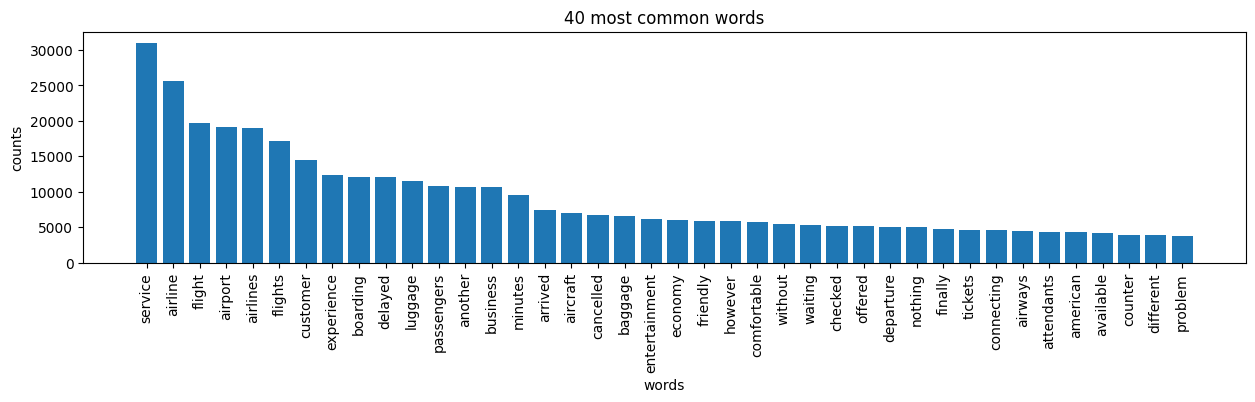

In [22]:
import numpy as np
terms = count_vectorizer.get_feature_names_out()

# Count the popularity of words
total_counts = np.zeros(len(terms))
for t in count_data:
    total_counts+=t.toarray()[0]

count_dict = (zip(terms, total_counts))
count_dict = sorted(count_dict, key=lambda x:x[1], reverse=True)[0:40]

words = [w[0] for w in count_dict]
counts = [w[1] for w in count_dict]
x_pos = np.arange(len(words))

pyplot.figure(2, figsize=(15, 3))
pyplot.subplot(title='40 most common words')
pyplot.bar(words, counts)
pyplot.xticks(x_pos, words, rotation=90)
pyplot.xlabel('words')
pyplot.ylabel('counts')
pyplot.show()

**Term Selection**

In [23]:
# Remove highly frequent (Greater than 40%) and infrequent words (less than 1%)
keepIndex = [];
for t in range(len(total_counts)):
    if total_counts[t] < 20000 and total_counts[t] > 500:
        keepIndex.append(t)

print('Number of Terms Remained: ', len(keepIndex))

# Save the remain ing term and frequency data
ReducedTerm = [terms[t] for t in keepIndex]
ReducedCount = count_data[:,keepIndex]
ReducedCount

Number of Terms Remained:  491


<50000x491 sparse matrix of type '<class 'numpy.int64'>'
	with 705105 stored elements in Compressed Sparse Row format>

# **LDA Modelling**

In [24]:
# Install Gensim Library
!pip install numpy
#!pip install Cython
!pip install gensim

**Data Preparation**

In [25]:
import gensim.corpora as corpora
from gensim.utils import simple_preprocess

# Tokenize each document
tokenized_docs = [simple_preprocess(doc) for doc in Cleaned_doc_no_stopwords]

# Construct term dictionary in the format "Term : Index"
id2word = corpora.Dictionary(tokenized_docs)

print(id2word.token2id)

{'aircraft': 0, 'airlines': 1, 'antonio': 2, 'atlanta': 3, 'botched': 4, 'carrier': 5, 'comfortable': 6, 'courteous': 7, 'destination': 8, 'experience': 9, 'frequent': 10, 'houston': 11, 'international': 12, 'itinerary': 13, 'morning': 14, 'orleans': 15, 'professional': 16, 'reached': 17, 'schedule': 18, 'service': 19, 'traveler': 20, 'unfortunately': 21, 'weather': 22, 'another': 23, 'canceled': 24, 'canceling': 25, 'connection': 26, 'flight': 27, 'flights': 28, 'otherwise': 29, 'outright': 30, 'perfectly': 31, 'rescheduled': 32, 'screwed': 33, 'thankfully': 34, 'together': 35, 'approach': 36, 'beautiful': 37, 'carefully': 38, 'course': 39, 'delays': 40, 'easyjet': 41, 'experienced': 42, 'friendly': 43, 'helpful': 44, 'landing': 45, 'lowcost': 46, 'luggage': 47, 'malpensa': 48, 'problems': 49, 'without': 50, 'airline': 51, 'chinese': 52, 'guangzhou': 53, 'noodles': 54, 'opinion': 55, 'request': 56, 'responsible': 57, 'southern': 58, 'absolutely': 59, 'actually': 60, 'airport': 61, 'al

In [26]:
# Bag of Word Representation
Corpus = [id2word.doc2bow(text) for text in tokenized_docs]
print(Corpus)


Output hidden; open in https://colab.research.google.com to view.

**Construct LDA model using gensim library**

In [27]:
import gensim
from gensim.models.ldamodel import LdaModel
from pprint import pprint

# Train LDA model using optimized parameters
lda_model = gensim.models.ldamodel.LdaModel(
    corpus=Corpus,
    id2word=id2word,
    num_topics=10,
    random_state=100,
    passes=5,
    iterations=50,
    eval_every=None
)

# Print the top 10 words for each topic
pprint(lda_model.print_topics(num_words=10))

# Assign topics to each document
doc_lda = lda_model[Corpus]


[(0,
  '0.035*"airport" + 0.033*"airlines" + 0.032*"istanbul" + 0.029*"airways" + '
  '0.026*"turkish" + 0.019*"singapore" + 0.017*"melbourne" + 0.016*"bangkok" + '
  '0.014*"jetstar" + 0.011*"transit"'),
 (1,
  '0.046*"service" + 0.026*"business" + 0.021*"entertainment" + 0.021*"flight" '
  '+ 0.019*"airlines" + 0.017*"comfortable" + 0.016*"flights" + '
  '0.015*"friendly" + 0.015*"aircraft" + 0.014*"economy"'),
 (2,
  '0.051*"customer" + 0.049*"service" + 0.026*"airline" + 0.020*"cancelled" + '
  '0.017*"flights" + 0.015*"booking" + 0.014*"tickets" + 0.014*"received" + '
  '0.012*"company" + 0.012*"website"'),
 (3,
  '0.054*"boarding" + 0.043*"minutes" + 0.040*"airport" + 0.027*"passengers" + '
  '0.024*"arrived" + 0.021*"departure" + 0.020*"delayed" + 0.019*"flight" + '
  '0.017*"security" + 0.016*"terminal"'),
 (4,
  '0.065*"airline" + 0.039*"baggage" + 0.033*"luggage" + 0.032*"checked" + '
  '0.026*"airlines" + 0.020*"charged" + 0.016*"experience" + 0.015*"airport" + '
  '0.014*"t

**Compute topic coherence score**

In [28]:
from gensim.models import CoherenceModel

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model,
                                     texts=tokenized_docs,
                                     dictionary=id2word,
                                     coherence='c_v')


coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  0.4830234848480256


**Experiment with Topic Numbers**

In [29]:
# Evaluation models with topics numbers from 2 to 35
Topics = list(range(2,36,1))
coherence_scores = []
Trained_Models = []
for top in Topics:
    lda_model = gensim.models.ldamodel.LdaModel(corpus=Corpus,
                                               id2word=id2word,
                                               num_topics=top,
                                               random_state=100)
    # Keep the trained models
    Trained_Models.append(lda_model)

    #Compute coherence score for each model
    coherence_model_lda = CoherenceModel(model=lda_model,
                                         texts=tokenized_docs,
                                         dictionary=id2word,
                                         coherence='c_v')
    coherence = coherence_model_lda.get_coherence()

    # Save and print the coherence scores
    coherence_scores.append(coherence)
    print('Topic Number: {0} -- Coherence: {1}'.format(top, coherence))

Topic Number: 2 -- Coherence: 0.5147855844731588
Topic Number: 3 -- Coherence: 0.5375701240231198
Topic Number: 4 -- Coherence: 0.5425203216541055
Topic Number: 5 -- Coherence: 0.5129330114514342
Topic Number: 6 -- Coherence: 0.522183661883334
Topic Number: 7 -- Coherence: 0.5181690573796855
Topic Number: 8 -- Coherence: 0.4917323309170862
Topic Number: 9 -- Coherence: 0.47230618813367997
Topic Number: 10 -- Coherence: 0.46727456616424873
Topic Number: 11 -- Coherence: 0.47641489352900096
Topic Number: 12 -- Coherence: 0.47534173214396663
Topic Number: 13 -- Coherence: 0.49737415283380826
Topic Number: 14 -- Coherence: 0.45273260083493794
Topic Number: 15 -- Coherence: 0.47565721436975955
Topic Number: 16 -- Coherence: 0.46051050201743815
Topic Number: 17 -- Coherence: 0.47376147757133097
Topic Number: 18 -- Coherence: 0.4708377882763105
Topic Number: 19 -- Coherence: 0.47745822873461086
Topic Number: 20 -- Coherence: 0.4792196578411344
Topic Number: 21 -- Coherence: 0.4555789113938945

Text(0, 0.5, 'Coherence')

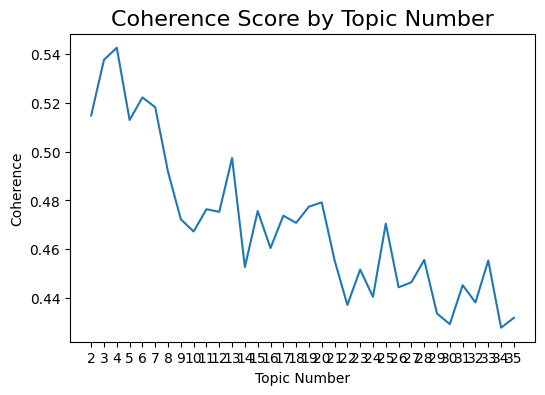

In [30]:
pyplot.figure(figsize=(6,4))
pyplot.plot(coherence_scores)
pyplot.xticks(range(0,len(Topics)),Topics)
pyplot.title('Coherence Score by Topic Number', fontsize=16)
pyplot.xlabel('Topic Number')
pyplot.ylabel('Coherence')

**The Best Model**

In [31]:
import numpy
lda_model = Trained_Models[numpy.argmax(coherence_scores)]

# Show top 10 words in each topic
lda_model.show_topics(num_words=10)

[(0,
  '0.021*"airline" + 0.016*"service" + 0.015*"airlines" + 0.012*"passengers" + 0.009*"customer" + 0.009*"flight" + 0.008*"experience" + 0.008*"luggage" + 0.008*"attendant" + 0.006*"customers"'),
 (1,
  '0.033*"service" + 0.021*"business" + 0.016*"airlines" + 0.016*"flight" + 0.015*"flights" + 0.014*"economy" + 0.014*"entertainment" + 0.013*"friendly" + 0.013*"comfortable" + 0.013*"experience"'),
 (2,
  '0.031*"airline" + 0.026*"customer" + 0.025*"service" + 0.019*"airport" + 0.017*"airlines" + 0.016*"delayed" + 0.016*"flights" + 0.015*"another" + 0.015*"cancelled" + 0.014*"flight"'),
 (3,
  '0.034*"boarding" + 0.028*"airport" + 0.027*"minutes" + 0.026*"luggage" + 0.019*"passengers" + 0.017*"arrived" + 0.016*"delayed" + 0.015*"flight" + 0.013*"baggage" + 0.011*"departure"')]

**Topic Modelling: Data Preparation and Process Overview**

---



To understand passengers’ concerns and interests when flying, topic modelling was conducted using a structured natural language processing approach. The process began with cleaning the text data, non alphabetic characters were removed, all words were lowercased, and short, less meaningful words were excluded. Then, common “stopwords” (e.g., the, and) were filtered out to focus only on relevant terms. A frequency matrix was created using CountVectorizer, highlighting the most common words in the reviews. Very frequent and rare words were also removed to reduce noise.

Next, the cleaned and tokenised data was transformed into a bag of words format. Using the Latent Dirichlet Allocation (LDA) model, topics were extracted based on word co-occurrence patterns. Coherence scores were calculated to evaluate topic quality, and the model was tested across different topic numbers (2 to 35) to find the most meaningful grouping.

**Train the Model Using 4 Topics - Highest Coherence**

In [32]:
from sklearn.decomposition import LatentDirichletAllocation as LDA

# Tweak the two parameters below
number_topics = 4

lda = LDA(n_components=number_topics, n_jobs=-1, random_state=2023)
lda.fit(ReducedCount)

# Trained LDA model
lda.components_

array([[  36.9208558 ,   57.4860551 ,  200.85023936, ...,  923.91327139,
          63.23795496,  383.59139012],
       [  76.91520655,  256.58536986,  370.92764567, ...,  575.66622254,
         621.66045791,  566.58903851],
       [ 444.75122341, 1332.74122648,   92.25092803, ..., 1662.1501195 ,
          38.88017321,  505.21512229],
       [ 181.41271425,  654.18734856,   95.97118694, ..., 2286.27038657,
          39.22141392,  583.60444909]])

**Word Probabilities by Topic**

In [33]:
# Word Probablities in Topics
Word_Topics_Pro = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]
print(Word_Topics_Pro)

[[0.00022196 0.00034559 0.00120744 ... 0.00555426 0.00038017 0.00230602]
 [0.00034439 0.00114888 0.00166085 ... 0.00257759 0.00278353 0.00253694]
 [0.00170106 0.00509739 0.00035284 ... 0.00635729 0.00014871 0.00193232]
 [0.0008373  0.00301936 0.00044295 ... 0.01055212 0.00018102 0.00269358]]


In [34]:
print(Word_Topics_Pro.shape)
# print(Word_Topics_Pro[1])

(4, 491)


**Extract and view the top words in each topic**

In [35]:
for topic_idx, topic in enumerate(Word_Topics_Pro):
    print("\nTopic #%d:" % topic_idx)
    count_dict = (zip(ReducedTerm, topic))
    count_dict = sorted(count_dict, key=lambda x:x[1], reverse=True)[0:10]
    for w in count_dict:
        print(w[0], ': {0:.3f}'.format(w[1]))


Topic #0:
boarding : 0.049
passengers : 0.046
minutes : 0.030
business : 0.030
flight : 0.025
airport : 0.022
aircraft : 0.019
arrived : 0.017
departure : 0.016
attendant : 0.014

Topic #1:
airlines : 0.036
flights : 0.031
entertainment : 0.026
flight : 0.026
business : 0.024
experience : 0.023
comfortable : 0.022
friendly : 0.022
economy : 0.021
airways : 0.019

Topic #2:
delayed : 0.040
airport : 0.033
airlines : 0.033
flights : 0.029
customer : 0.026
another : 0.025
flight : 0.024
cancelled : 0.021
american : 0.016
connecting : 0.014

Topic #3:
luggage : 0.038
customer : 0.035
airport : 0.026
baggage : 0.019
checked : 0.016
tickets : 0.016
flight : 0.016
booking : 0.014
boarding : 0.013
website : 0.013


In [36]:
# View full Word Probabilities by Topic Matrix
sample_df_topic_keywords = pd.DataFrame(Word_Topics_Pro)
sample_df_topic_keywords.columns = ReducedTerm
sample_df_topic_keywords

,absolute,absolutely,acceptable,accommodation,account,actually,addition,additional,adequate,advance,...,website,welcome,westjet,whatsoever,wheelchair,whether,willing,without,wonderful,working
0,0.000222,0.000346,0.001207,0.000176,0.000010,0.001832,0.000393,0.000469,0.000691,0.000351,...,0.000012,2.420028e-03,0.000002,0.000289,0.003173,0.000759,0.000198,0.005554,0.000380,0.002306
1,0.000344,0.001149,0.001661,0.000034,0.000012,0.002083,0.000584,0.000488,0.001876,0.000612,...,0.000049,1.230863e-03,0.000258,0.000308,0.000001,0.000376,0.000503,0.002578,0.002784,0.002537
2,0.001701,0.005097,0.000353,0.002024,0.000207,0.002979,0.000491,0.002254,0.000002,0.000839,...,0.000041,9.762471e-07,0.004232,0.000937,0.000328,0.000411,0.000836,0.006357,0.000149,0.001932
3,0.000837,0.003019,0.000443,0.000513,0.002361,0.003074,0.001084,0.004864,0.000002,0.003119,...,0.012800,1.358257e-06,0.000011,0.000772,0.000010,0.000928,0.001325,0.010552,0.000181,0.002694


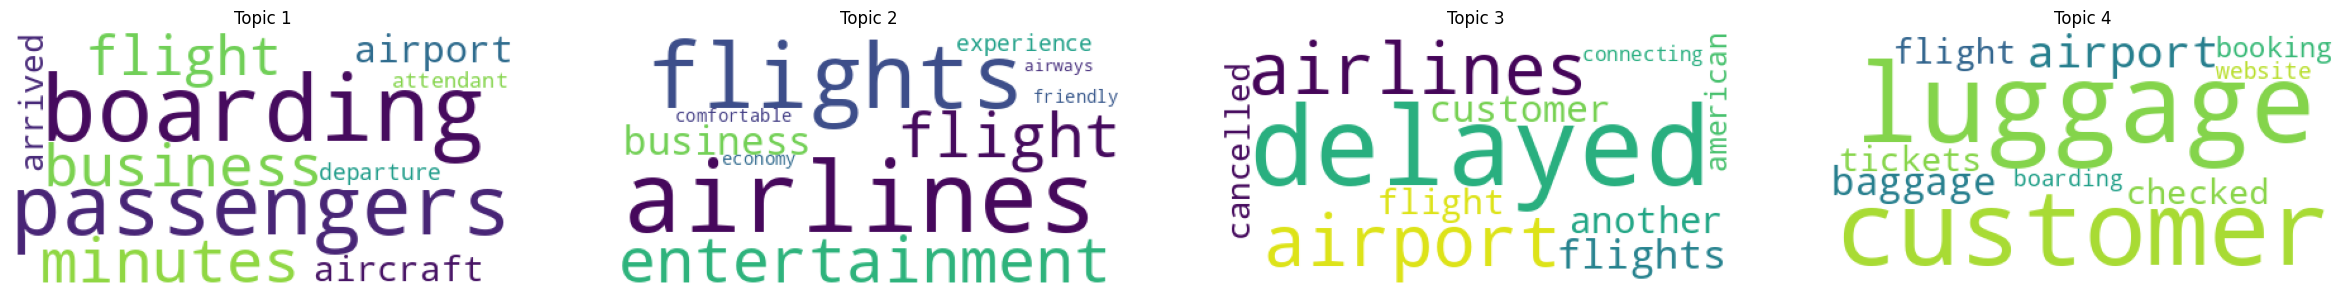

In [37]:
from wordcloud import WordCloud
import math

rows = math.ceil(len(Word_Topics_Pro)/4)
fig, ax = pyplot.subplots(rows, 4, figsize=(30,20*rows))

if rows == 1:
    ax = ax.ravel()
else:
    [axi.set_axis_off() for axi in ax.ravel()]


for topic_idx, topic in enumerate(Word_Topics_Pro):
    count_dict = (zip(ReducedTerm, topic))
    count_dict = sorted(count_dict, key=lambda x:x[1], reverse=True)

    # convert to dictionary type - keep top 10 words
    Word_Frequency = dict(count_dict[0:10])

    # generate word cloud
    wordcloud = WordCloud(background_color="white").generate_from_frequencies(Word_Frequency)

    # visualize word cloud in figure
    subfig_Row = math.floor(topic_idx/4)
    subfig_Col = math.ceil(topic_idx%4)

    if rows == 1:
      ax[subfig_Col].imshow(wordcloud)
      ax[subfig_Col].set_title("Topic {}".format(topic_idx+1))
      ax[subfig_Col].set_axis_off()
    else:
      ax[subfig_Row,subfig_Col].imshow(wordcloud)
      ax[subfig_Row,subfig_Col].set_title("Topic {}".format(topic_idx+1))
      ax[subfig_Row,subfig_Col].set_axis_off()


pyplot.show()

**Compute the popularity of topics over the entire data set to identify the most popular topics**

In [38]:
# Compute topic distribution for each document
TopicDis_Doc = lda.transform(ReducedCount)

# Compute overall topic distribution for all each documents
Overall_Topic_Dis = sum(TopicDis_Doc)/sum(sum(TopicDis_Doc))
Overall_Topic_Dis

array([0.18234923, 0.28922532, 0.28718948, 0.24123597])

**Visualize the topic distribution using bar chart**

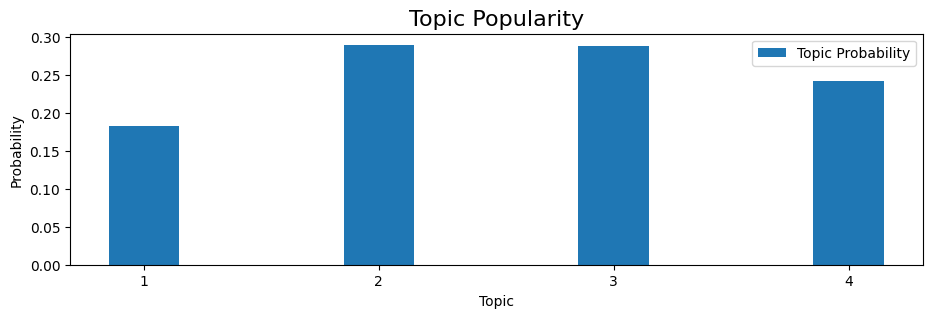

In [39]:
# Get the topic index
Bar_index = np.asarray(range(1,number_topics+1))

# Visualize topic distributions of review groups
pyplot.figure(figsize=(11,3))
pyplot.title('Topic Popularity', fontsize=16)
pyplot.xlabel('Topic')
pyplot.ylabel('Probability')
pyplot.bar(Bar_index, Overall_Topic_Dis.tolist(), 0.3, label='Topic Probability')
pyplot.xticks(Bar_index, Bar_index)
pyplot.legend()
pyplot.show();

**Topic Probabilities by Document**

In [40]:
# View full Topic Probabilities by Document Matrix
TopicDis_Doc = lda.transform(ReducedCount)
sample_df_document_topics = pd.DataFrame(TopicDis_Doc)
sample_df_document_topics

,0,1,2,3
0,0.012603,0.459553,0.515341,0.012504
1,0.023927,0.024321,0.927041,0.024712
2,0.360652,0.442346,0.026456,0.170547
3,0.867805,0.044554,0.041780,0.045860
4,0.004107,0.004052,0.147895,0.843946
...,...,...,...,...
49995,0.019064,0.018589,0.223832,0.738515
49996,0.008681,0.650153,0.008416,0.332750
49997,0.010836,0.567954,0.410345,0.010864
49998,0.261565,0.018161,0.227134,0.493140


**Key Passenger Concerns and Interests Identified Through Topic Modelling**

---



Topic modelling revealed four core themes that reflect what matters most to airline passengers. The first theme centres on the boarding process, with frequent mentions of “boarding,” “passengers,” “minutes,” and “airport,” pointing to concerns around punctuality, check in efficiency, and coordination at departure gates.


The second theme highlights the in-flight experience, where words like “entertainment,” “comfortable,” “friendly,” and “experience” suggest that passengers place high importance on comfort and enjoyment during the journey, especially in business and economy class.


The third theme reflects operational issues, as terms such as “delayed,” “cancelled,” and “connecting” show recurring frustration with flight disruptions and schedule inconsistencies. Passengers also frequently mention “customer,” indicating that communication and support play a critical role when things go wrong.


The final theme focuses on luggage and booking processes, with keywords like “luggage,” “checked,” “baggage,” and “website” revealing ongoing concerns about baggage handling, ticketing systems, and digital experience.

Among these themes, in flight experience and delay related concerns emerged as the most prominent, followed closely by luggage related issues. Boarding concerns appeared least frequently, suggesting that passengers are more focused on service quality and operational disruptions than on initial boarding procedures.

#**4.2 PART F**

**Topic Probabilities by Document Group**

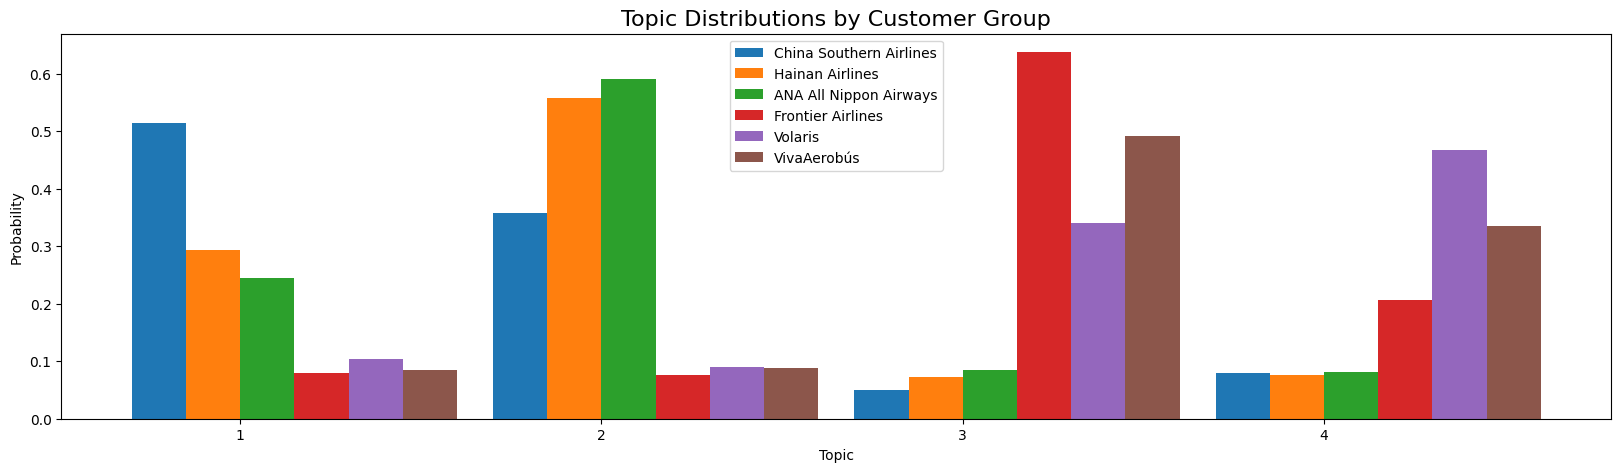

In [41]:
# Corrected list of selected countries
Selected_Countries = ['China Southern Airlines','Hainan Airlines','ANA All Nippon Airways','Frontier Airlines', 'Volaris', 'VivaAerobús']

Group_Prob = []
for i in range(len(Selected_Countries)):
    ReducedTerm_Selected = ReducedCount[np.where(sample_df['AirlineName'] == Selected_Countries[i])]
    TopicDis_Doc = lda.transform(ReducedTerm_Selected)
    Group_Prob.append(sum(TopicDis_Doc)/sum(sum(TopicDis_Doc)))


# Create a new figure
pyplot.figure(figsize=(20,5))
pyplot.title('Topic Distributions by Customer Group', fontsize=16)
pyplot.xlabel('Topic')
pyplot.ylabel('Probability')

width = 0.15
for i in range(len(Selected_Countries)):
    pyplot.bar(Bar_index + i*width, Group_Prob[i].tolist(), width,  label=Selected_Countries[i])

pyplot.xticks(Bar_index + 1.5*width, Bar_index)
pyplot.legend()
pyplot.show();

**Differences in Passenger Concerns: Top vs. Bottom Rated Airlines**

---



A comparison of topic distributions reveals noticeable differences in the concerns and interests of passengers flying with the top three rated airlines China Southern Airlines, Hainan Airlines, and ANA All Nippon Airways versus those travelling with the bottom three Frontier Airlines, Volaris, and VivaAerobús.

For the top rated airlines, Topic 1 (boarding process) and Topic 2 (in flight experience) dominate customer reviews. Over 50% of feedback for China Southern Airlines, and around 60% for ANA and Hainan Airlines, revolves around punctuality, seating comfort, and in flight entertainment. This indicates that passengers flying with these airlines are generally focused on the quality of service, efficiency, and comfort, likely because the core service expectations are already being met consistently. These reviews suggest customers are evaluating refinements in experience rather than reacting to service failures.

In contrast, reviews for the bottom three airlines are heavily concentrated around Topic 3 (delays and disruptions) and Topic 4 (luggage and booking issues). Frontier Airlines, in particular, shows an overwhelming focus on Topic 3, indicating significant dissatisfaction with flight reliability and customer service during disruptions. Volaris and VivaAerobús show stronger associations with baggage complaints and issues related to online booking or support services.



---



---



# **5. PRACTICAL IMPLICATIONS**

**Practical Implications and Recommendations**

---



1. Consistent high performers, such as Hainan Airlines and ANA All Nippon Airways demonstrate that delivering strong performance across multiple service dimensions, particularly in flight comfort, entertainment, and punctuality, drives both higher overall scores and positive sentiment. Therefore, investment in in flight experience (e.g., seat comfort, entertainment systems, attentive cabin crew) should be prioritized (Cheng et al., 2019).

2. The analysis highlighted that service inconsistencies, particularly around delays, baggage handling, and digital booking processes are key drivers of negative sentiment and poor ratings. Qantas and Jetstar, while not in the bottom tier, remain mid ranked and risk losing competitive ground. To address this, targeted interventions should focus on improving operational reliability, enhancing real time communication during disruptions, and upgrading digital touchpoints for smoother booking and baggage tracking (Santos & Fernandes, 2020).

3. Customer sentiment also revealed that travelers value responsiveness and transparency. Airlines receiving high recommendation rates often demonstrate strong post service recovery strategies, which include proactive communication and efficient resolution of issues. Integrating customer service analytics into operations can help flag recurring complaints, enabling timely service recovery (Jiang & Zhang, 2016).

4. Segment specific strategies should be explored. For instance, business class passengers show higher expectations and less tolerance for inconsistencies (Park & Kwon, 2021). Tailored loyalty programs, priority services, and consistent onboard quality can strengthen brand perception within this high value segment.

5. Leveraging topic modelling insights can help airlines monitor shifts in customer priorities over time. As review volumes and patterns evolve, maintaining this feedback loop will enable the airline to respond dynamically to changing expectations.

---
## Portfolio Note

This notebook is a portfolio presentation of the original analysis. Assessment-specific headings and personal identifiers have been removed, while the analytical code, methodology, outputs, interpretations and references have been preserved.

# **References**


Aksoy, S., Bugra Koçoğlu, C., & Atilgan İnanan, C. (2020). Investigating the relationship between travel purpose and airline service satisfaction. Journal of Hospitality and Tourism Management, 45, 1-9. https://doi.org/10.1016/j.jhtm.2020.05.008

Baker, D. M. A., Stockton, S., & Howell, D. (2013). Evaluating service quality and customer satisfaction in the airline industry: A comparison between legacy airlines and low-cost carriers. Journal of Aviation/Aerospace Education & Research, 23(2). https://doi.org/10.15394/jaaer.2013.1438

Cheng, Y. H., Lee, S. H., & Lee, T. C. (2019). Measuring multi-dimensional airline service quality and its impact on overall passenger satisfaction. Journal of Air Transport Management, 75, 185-197. https://doi.org/10.1016/j.jairtraman.2018.11.004

Jiang, H., & Zhang, Y. (2016). An investigation of service recovery strategy and customer post-complaint behavior in the airline industry: A Chinese perspective. Journal of Air Transport Management, 57, 1-8. https://doi.org/10.1016/j.jairtraman.2016.07.001

Li, M., Wang, Y., Zhang, X., & Lu, W. (2021). Cultural differences in online airline reviews: Evidence from TripAdvisor. Journal of Air Transport Management, 96, 102077. https://doi.org/10.1016/j.jairtraman.2021.102077

Loo, B. P. Y., & Leung, L. (2020). Airline strategies and customer satisfaction: The role of digital service enhancements such as in-flight Wi-Fi. Transport Policy, 96, 38-47. https://doi.org/10.1016/j.tranpol.2020.07.005

Park, J., & Kwon, Y. (2021). Business traveler satisfaction in premium cabins: A segmentation approach. Journal of Hospitality and Tourism Management, 46, 169-176. https://doi.org/10.1016/j.jhtm.2020.12.002

Santos, G., & Fernandes, E. (2020). Passenger perceptions of airline service quality: A critical incident approach. Journal of Air Transport Management, 89, 101875. https://doi.org/10.1016/j.jairtraman.2020.101875



